In [4]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import transform_to_sequence
from seq_models import SeqDataset, collate_fn, LSTMClassifier, TransformerClassifier, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Bank](https://www.openml.org/search?type=data&id=1461&sort=runs&status=active)

In [5]:
dataset_id = 1461
train_data, valid_data, test_data, train_labels, valid_labels, test_labels, _, _ = get_openml_data(dataset_id, transform_func=transform_to_sequence)

In [6]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


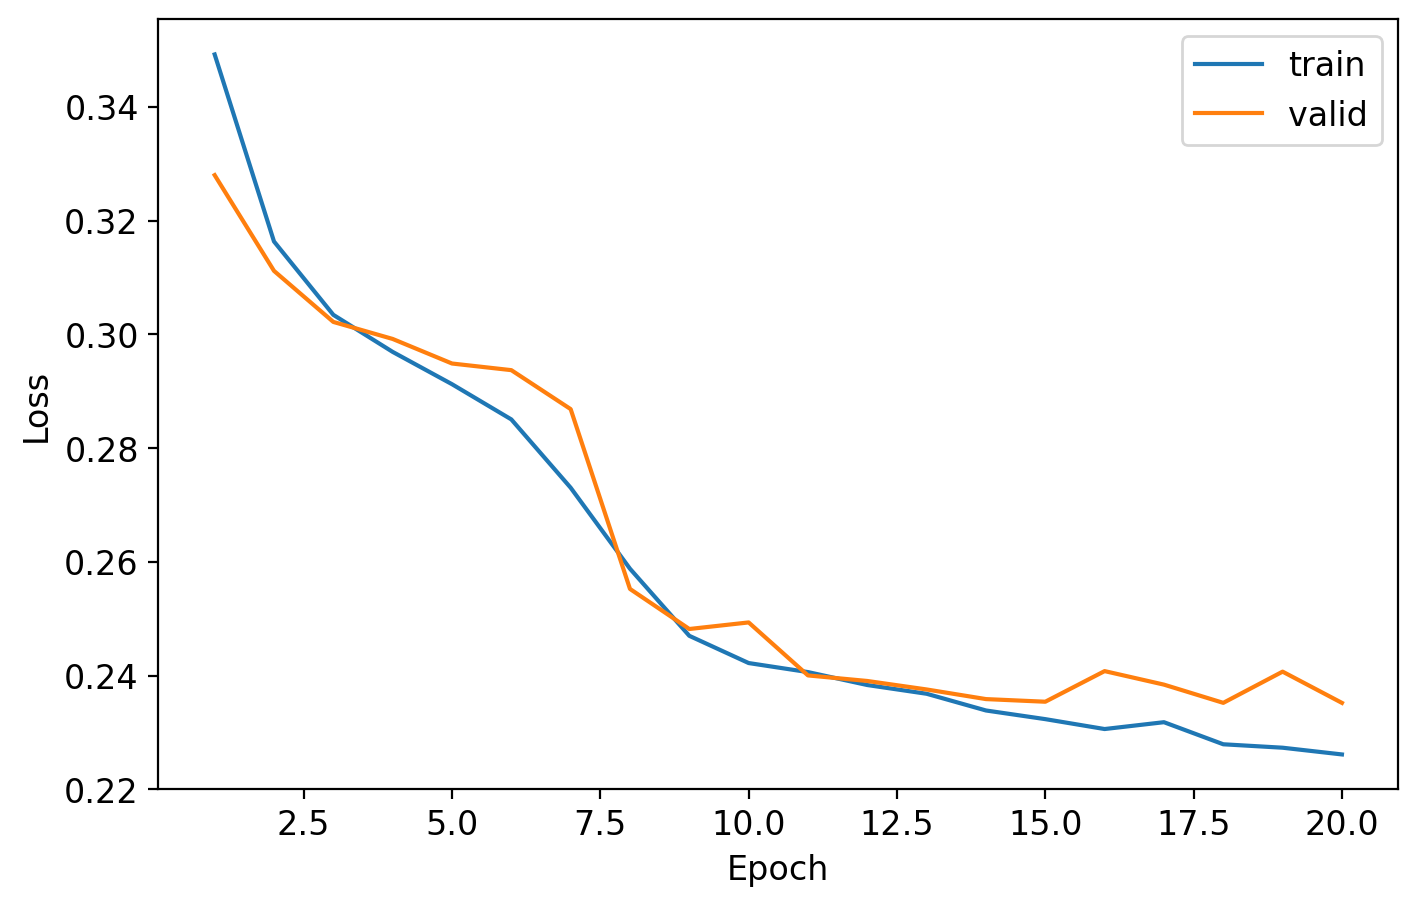

Epoch 20: train loss = 0.2261; valid loss = 0.2352


In [8]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 20, train_loader, valid_loader, criterion, device, scheduler=None)

In [9]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
metrics_lstm = bootstrap_metrics(y_true, y_pred, y_prob)

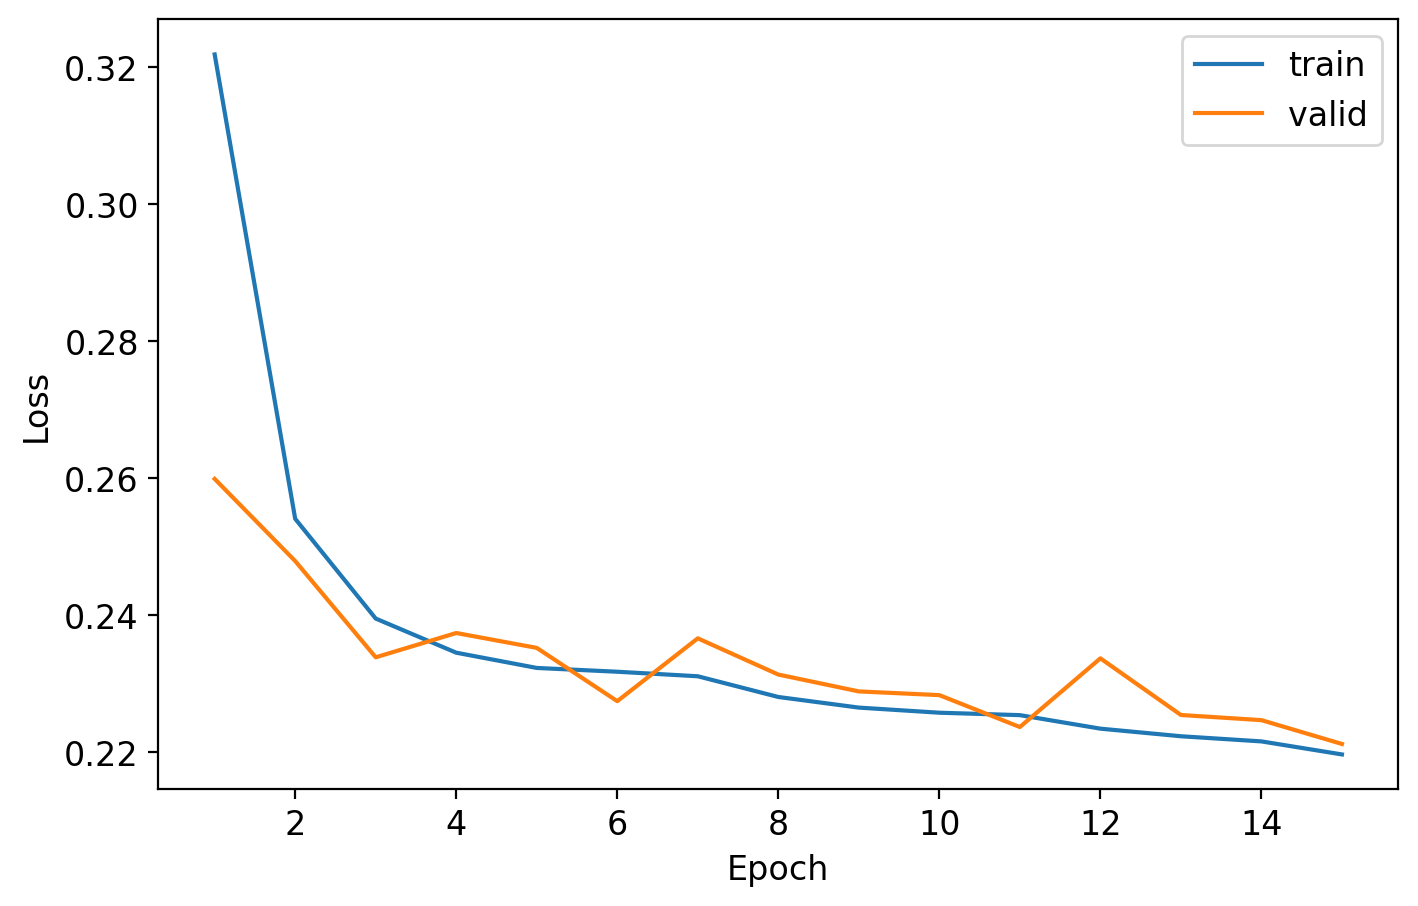

Epoch 15: train loss = 0.2197; valid loss = 0.2212


In [10]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 15, train_loader, valid_loader, criterion, device, scheduler=None)

In [11]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
metrics_enc = bootstrap_metrics(y_true, y_pred, y_prob)

In [12]:
res = pd.DataFrame([{"model": "LSTM"} | metrics_lstm, {"model": "Transformer"} | metrics_enc])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,LSTM,0.9027±0.0062,0.5076±0.0205,0.8964±0.0046,0.5716±0.0250,0.4569±0.0220
1,Transformer,0.9127±0.0056,0.4950±0.0214,0.9041±0.0043,0.6446±0.0266,0.4021±0.0216
